In [1]:
from alna import load_love_numbers_for_gins
from numpy import array
from gins_partials.tide_correction_model import REFERENCE_K2, IERS_LONG_PERIOD_ZONAL_TIDES

k2_reference = array(
    [
        REFERENCE_K2 + delta_k2_r + 1j * k2_i
        for _, _, delta_k2_r, k2_i in IERS_LONG_PERIOD_ZONAL_TIDES
    ]
)
tabs, love_number_log_frequencies, elastic, love_numbers, _ = load_love_numbers_for_gins()

In [2]:
from gins_partials.tide_correction_model import (
    tide_angular_frequencies_to_cycle_per_yr,
    interpolate_love_number_grid_to_solid_tides,
)

interpolated_love_numbers = interpolate_love_number_grid_to_solid_tides(
    model_grid=love_numbers,
    love_number_log_frequencies=love_number_log_frequencies,
    solid_tide_frequencies=tide_angular_frequencies_to_cycle_per_yr(),
)

In [3]:
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import least_squares
from numpy.random import uniform

grids = tuple(tabs.values())
interpolators = [
    RegularGridInterpolator(
        grids,
        interpolated_love_numbers[..., i],
        method="cubic",
        bounds_error=False,
        fill_value=None,
    )
    for i in range(len(k2_reference))
]
lower_bounds = array([0.24, 2, -2, 2])
upper_bounds = array([0.26, 4, 1, 5])


def predict(p):
    p = array(p, dtype=float)
    return array([complex(interpolator(p)[0]) for interpolator in interpolators])


def residuals(p):
    return abs(predict(p) - array(k2_reference, dtype=complex))


result = least_squares(
    residuals,
    x0=array([uniform(low=low, high=high) for low, high in zip(lower_bounds, upper_bounds)]),
    bounds=(lower_bounds, upper_bounds),
)

In [4]:
cost = result.cost
x = result.x
print(
    "Solution:\n" + "\n".join(f"{parameter} = {value}" for parameter, value in zip(tabs.keys(), x))
)
print("Relative error:", cost / REFERENCE_K2)

Solution:
\alpha^{MANTLE_0} = 0.24000000000000218
\log_{10}Q_\mu^{MANTLE_0} = 3.532841194340027
\log_{10}\Delta^{MANTLE_0} = 0.9999537802768049
\log_{10}\tau_{m-inf}^{MANTLE_0} = 2.0000004683621873
Relative error: 4.919333565148719e-05


In [5]:
from alna.rheological_formulas import find_tau_m_sup

# TODO: Raise compatibility questions.
print(find_tau_m_sup(omega_m_inf=3.09e-4, period_unit=1, alpha=0.25, delta=1, q_mu=1000) / 3600/24/365.25)

9.779474993280783


In [6]:
from alna.rheological_formulas import find_tau_m_sup

print(find_tau_m_sup(omega_m_inf=10**(-x[3]), period_unit=1, alpha=x[0], delta=10**(x[2]), q_mu=10**(x[1])) / 3600/24/365.25)

29747.90398158948


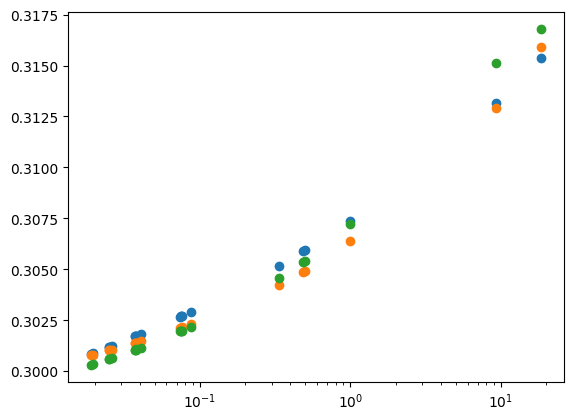

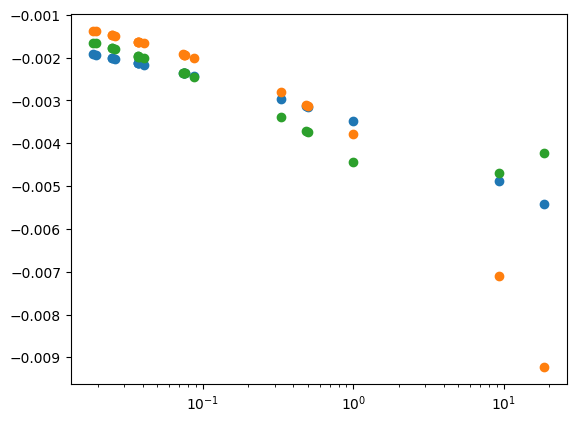

In [12]:
from matplotlib.pyplot import scatter, xscale, show

log_Q_to_test = 3.5
xscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.real)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).real,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict((0.25, log_Q_to_test, -0.9, 3.5)).real,
)
show()

xscale("log")
scatter(1 / tide_angular_frequencies_to_cycle_per_yr(), k2_reference.imag)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict(x).imag,
)
scatter(
    1 / tide_angular_frequencies_to_cycle_per_yr(),
    predict((0.25, log_Q_to_test, -0.9, 3.5)).imag,
)
show()